All imports done!
Dataset 1 exists: True
Dataset 2 exists: True
Dataset 3 exists: True

--- Dataset 1 (Train) ---
  NORMAL: 1341 images
  PNEUMONIA: 3875 images
  TOTAL: 5216 images

--- Dataset 2 (Val) ---
  NORMAL: 8 images
  PNEUMONIA: 8 images
  TOTAL: 16 images

--- Dataset 3 (Test) ---
  NORMAL: 234 images
  PNEUMONIA: 390 images
  TOTAL: 624 images


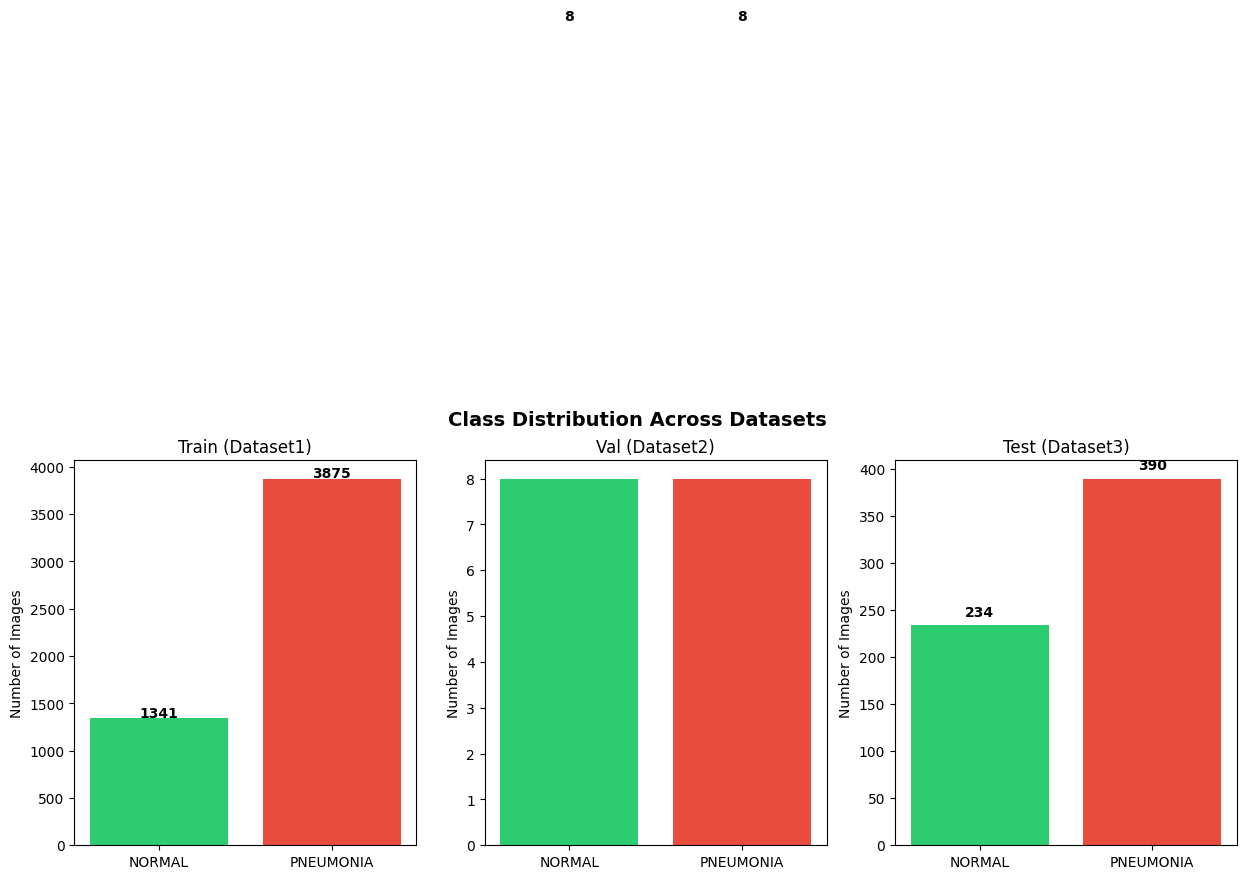

Chart saved!


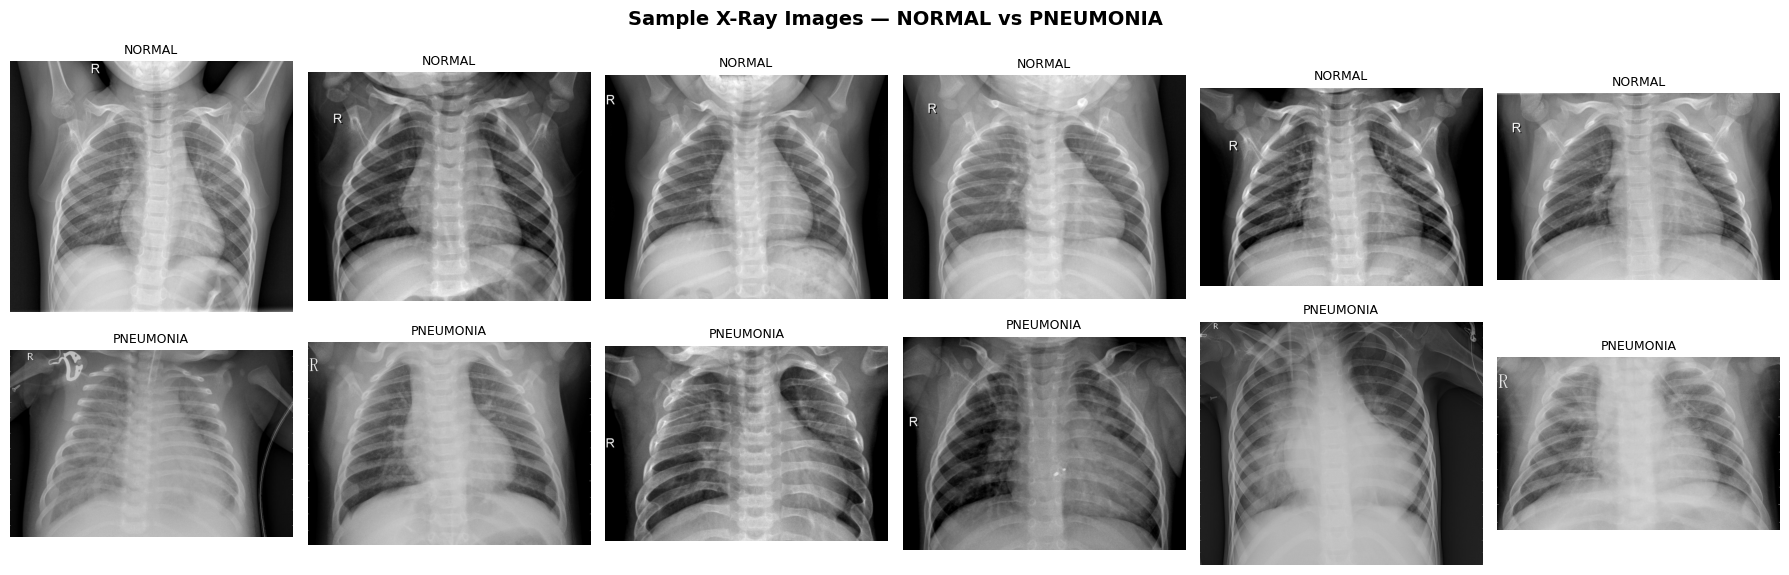

Sample images saved!
Loading Dataset 1 (Train)...
Done! Shape: (5216, 16384)

Loading Dataset 2 (Val)...
Done! Shape: (16, 16384)

Loading Dataset 3 (Test)...
Done! Shape: (624, 16384)
Scaling done!
PCA done!

Variance explained by 100 components: 87.88%


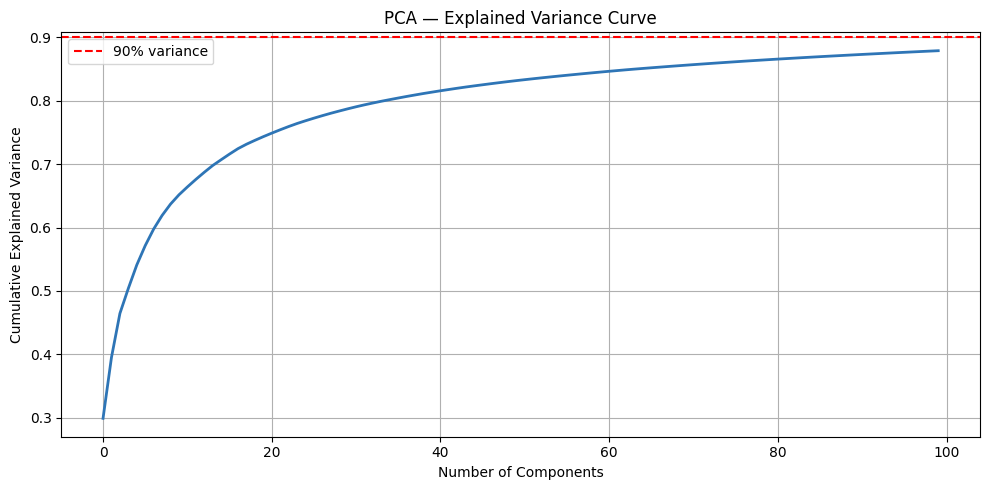

PCA chart saved!


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Dataset Paths
DATASET1 = '../data/train'
DATASET2 = '../data/val'
DATASET3 = '../data/test'

print("All imports done!")
print("Dataset 1 exists:", os.path.exists(DATASET1))
print("Dataset 2 exists:", os.path.exists(DATASET2))
print("Dataset 3 exists:", os.path.exists(DATASET3))

def explore_dataset(path, name):
    print(f"\n--- {name} ---")
    total = 0
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"  {label}: {len(files)} images")
        total += len(files)
    print(f"  TOTAL: {total} images")

explore_dataset(DATASET1, 'Dataset 1 (Train)')
explore_dataset(DATASET2, 'Dataset 2 (Val)')
explore_dataset(DATASET3, 'Dataset 3 (Test)')

# Class distribution bar charts
datasets = {
    'Train (Dataset1)': DATASET1,
    'Val (Dataset2)': DATASET2,
    'Test (Dataset3)': DATASET3
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, path) in zip(axes, datasets.items()):
    counts = []
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        counts.append(len(files))
    
    ax.bar(['NORMAL', 'PNEUMONIA'], counts, color=['#2ecc71', '#e74c3c'])
    ax.set_title(name)
    ax.set_ylabel('Number of Images')
    for i, v in enumerate(counts):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

# Show sample X-ray images
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for col, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(DATASET1, label)
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:6]
    
    for row, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('L')
        axes[col][row].imshow(img, cmap='gray')
        axes[col][row].set_title(label, fontsize=9)
        axes[col][row].axis('off')

plt.suptitle('Sample X-Ray Images — NORMAL vs PNEUMONIA', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/sample_xrays.png', dpi=150)
plt.show()
print("Sample images saved!")

def load_dataset(path, size=(128, 128)):
    X, y = [], []
    for label, val in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder = os.path.join(path, label)
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for fname in files:
            try:
                img = Image.open(os.path.join(folder, fname)).convert('L')
                img = img.resize(size)
                X.append(np.array(img).flatten() / 255.0)
                y.append(val)
            except:
                print(f"Skipped corrupt file: {fname}")
    return np.array(X), np.array(y)

print("Loading Dataset 1 (Train)...")
X_train_raw, y_train = load_dataset(DATASET1)
print(f"Done! Shape: {X_train_raw.shape}")

print("\nLoading Dataset 2 (Val)...")
X_val_raw, y_val = load_dataset(DATASET2)
print(f"Done! Shape: {X_val_raw.shape}")

print("\nLoading Dataset 3 (Test)...")
X_test_raw, y_test = load_dataset(DATASET3)
print(f"Done! Shape: {X_test_raw.shape}")

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1 — Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)
print("Scaling done!")

# Step 2 — Apply PCA
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("PCA done!")

# Step 3 — Print variance explained
variance = pca.explained_variance_ratio_.sum()
print(f"\nVariance explained by 100 components: {variance:.2%}")

# Step 4 — Plot variance curve
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), color='#2E75B6', linewidth=2)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../outputs/figures/pca_variance.png', dpi=150)
plt.show()
print("PCA chart saved!")

In [12]:
# Final summary — everything ready for Person B
print("=" * 50)
print("PREPROCESSING COMPLETE — READY FOR PERSON B")
print("=" * 50)

print(f"\nX_train_pca shape : {X_train_pca.shape}")
print(f"y_train shape     : {y_train.shape}")
print(f"  Normal    : {(y_train==0).sum()}")
print(f"  Pneumonia : {(y_train==1).sum()}")

print(f"\nX_val_pca shape   : {X_val_pca.shape}")
print(f"y_val shape       : {y_val.shape}")

print(f"\nX_test_pca shape  : {X_test_pca.shape}")
print(f"y_test shape      : {y_test.shape}")

print(f"\nPCA components    : 100")
print(f"Variance explained: 87.88%")
print(f"\nAll features scaled and PCA applied!")
print("Person B can now use X_train_pca, X_val_pca, X_test_pca")

PREPROCESSING COMPLETE — READY FOR PERSON B

X_train_pca shape : (5216, 100)
y_train shape     : (5216,)
  Normal    : 1341
  Pneumonia : 3875

X_val_pca shape   : (16, 100)
y_val shape       : (16,)

X_test_pca shape  : (624, 100)
y_test shape      : (624,)

PCA components    : 100
Variance explained: 87.88%

All features scaled and PCA applied!
Person B can now use X_train_pca, X_val_pca, X_test_pca
